In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from kneed import KneeLocator
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.colors as colors
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset
import torch.nn.functional as F

In [3]:
"""
def apply_mask(image_path, mask_path):
    # Preparing image
    raster_img = rio.open(image_path)                  # get image with image path
    arr_img = reshape_as_image(raster_img.read())      # turn it into an array
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    mask_zero = np.all(arr_img == 0, axis=2)
    arr_img[(~mask_norm) | (mask_zero)] = np.nan
    image = reshape_as_raster(arr_img)
    l, m, n = image.shape                              # check the size of the image 
    #print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))
    X = image.reshape(l, -1).T                         # image reshaped as (mxn), l
    scaler = StandardScaler()                                     
    X_scaled = scaler.fit_transform(X)                 # scale the data

    # Preparing mask
    with rio.open(mask_path) as src:
        image = src.read(1)                            # Lire la première bande
    mask_soil = (image > 0).astype(np.uint8)           # 0 is mask, 1 is image
    
    unique, counts = np.unique(mask_soil, return_counts=True)
    print(dict(zip(unique, counts)))
    
    mask_soil_elargi = mask_soil[:,:,np.newaxis]       # so the mask covers all of the spectral bands
    vec_new = np.repeat(mask_soil_elargi,  X_scaled.shape[1], axis=2)  # shape = (m, n, l)
    X_scaled_soil = X_scaled.reshape(m,n,l)*vec_new    # reshape the image to apply the mask correctly
    RED = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)
    print(rgb.shape, len(rgb), rgb.shape[0]*rgb.shape[1]*rgb.shape[2])
    print("count is", abs(np.count_nonzero(rgb) - rgb.shape[0]*rgb.shape[1]*rgb.shape[2]))
    
    min_val = np.nanmin(rgb, axis=(0,1))               # normalize band by band
    max_val = np.nanmax(rgb, axis=(0,1))               
    scale = max_val - min_val                          # Avoid to divide by 0
    scale[scale == 0] = 1                              # change 0 by 1 to avoid warnings
    rgb_norm = (rgb - min_val) / scale                 # normalize the rgb image
    
    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()
    return rgb_norm
"""

'\ndef apply_mask(image_path, mask_path):\n    # Preparing image\n    raster_img = rio.open(image_path)                  # get image with image path\n    arr_img = reshape_as_image(raster_img.read())      # turn it into an array\n    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)\n    mask_zero = np.all(arr_img == 0, axis=2)\n    arr_img[(~mask_norm) | (mask_zero)] = np.nan\n    image = reshape_as_raster(arr_img)\n    l, m, n = image.shape                              # check the size of the image \n    #print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))\n    X = image.reshape(l, -1).T                         # image reshaped as (mxn), l\n    scaler = StandardScaler()                                     \n    X_scaled = scaler.fit_transform(X)                 # scale the data\n\n    # Preparing mask\n    with rio.open(mask_path) as src:\n        image = src.read(1)                            # Lire la première bande\n    mask_soil = (image > 0).astype(np.uint8)   

In [4]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

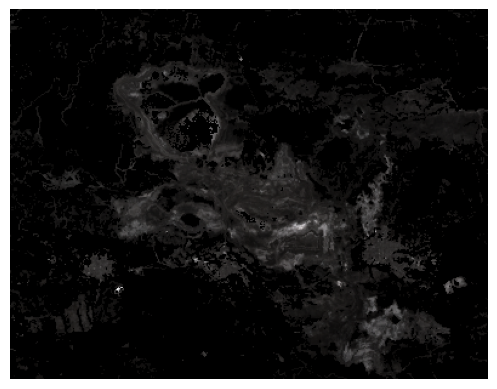

In [8]:
soil_only, fond_soil = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                       r"./INSA_cropped_2_EnMAP_20240508_mask_SOIL_SAVI_DSBI.tiff")

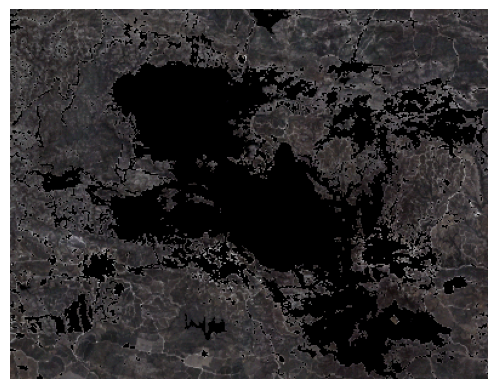

In [9]:
vegetation_only, fond_vegetation = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                             r"./INSA_cropped_2_EnMAP_20240508_mask_NDVI.tiff")

In [ ]:
'''def compute_ndvi(nir, red):
    nir = nir.astype(float)
    red = red.astype(float)
    
    ndvi = (nir - red) / (nir + red)
    
    # Évite les divisions par zéro
    ndvi = np.where((nir + red) == 0, 0, ndvi)
    
    return ndvi, nir

# Exemple d'utilisation :
ndvi, nir = compute_ndvi(image[-1,:,:], image[2,:,:])'''

"def compute_ndvi(nir, red):\n    nir = nir.astype(float)\n    red = red.astype(float)\n    \n    ndvi = (nir - red) / (nir + red)\n    \n    # Évite les divisions par zéro\n    ndvi = np.where((nir + red) == 0, 0, ndvi)\n    \n    return ndvi, nir\n\n# Exemple d'utilisation :\nndvi, nir = compute_ndvi(image[-1,:,:], image[2,:,:])"

In [ ]:
'''
# Seuil NDVI (à ajuster selon ton cas)
threshold_ndvi = 0.3
#threshold_nir = 2800

# Mask binaire : 1 = végétation, 0 = non-végétation
veg_mask = (ndvi > threshold_ndvi) #& (nir > threshold_nir)

# On étend le mask en 3D pour l’appliquer aux bandes
veg_mask_3d = veg_mask[None, :, :]  # shape -> (H, W, 1)

# Array final : mêmes dimensions, pixels non végétation = 0
veg_only = np.where(veg_mask_3d, image, 0)

# Indices Sentinel-2 : (si image = [B1, B2, B3, B4, B5, ...])
RED   = veg_only[2, :, :]
GREEN = veg_only[1, :, :]
BLUE  = veg_only[0, :, :]

rgb = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb, axis=(0,1))
max_val = np.nanmax(rgb, axis=(0,1))

# Évite division par zéro
scale = max_val - min_val
scale[scale == 0] = 1  # remplacer 0 par 1 pour éviter le warning

rgb_norm = (rgb - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"\n# Seuil NDVI (à ajuster selon ton cas)\nthreshold_ndvi = 0.3\n#threshold_nir = 2800\n\n# Mask binaire : 1 = végétation, 0 = non-végétation\nveg_mask = (ndvi > threshold_ndvi) #& (nir > threshold_nir)\n\n# On étend le mask en 3D pour l’appliquer aux bandes\nveg_mask_3d = veg_mask[None, :, :]  # shape -> (H, W, 1)\n\n# Array final : mêmes dimensions, pixels non végétation = 0\nveg_only = np.where(veg_mask_3d, image, 0)\n\n# Indices Sentinel-2 : (si image = [B1, B2, B3, B4, B5, ...])\nRED   = veg_only[2, :, :]\nGREEN = veg_only[1, :, :]\nBLUE  = veg_only[0, :, :]\n\nrgb = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb, axis=(0,1))\nmax_val = np.nanmax(rgb, axis=(0,1))\n\n# Évite division par zéro\nscale = max_val - min_val\nscale[scale == 0] = 1  # remplacer 0 par 1 pour éviter le warning\n\nrgb_norm = (rgb - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show()\n"

In [ ]:
'''
# Pixels restants (non-végétation)
non_veg_mask = ~veg_mask

# Extraire bandes nécessaires
green = image[1, :, :]  # B3
nir   = image[-1, :, :]  # B8

# Calcul NDWI
ndwi = (green - nir) / (green + nir)
ndwi = np.where((green + nir) == 0, 0, ndwi)

# Détection de l'eau
threshold_ndwi = 0  # à ajuster
water_mask = (ndwi > threshold_ndwi) & non_veg_mask

# Étendre le masque sur les bandes
water_mask_3d = water_mask[None, :, :]

# Pixels eau gardés, autres = 0
water_only = np.where(water_mask_3d, image, 0)

RED   = water_only[2, :, :] #+ veg_only[2, :, :]
GREEN = water_only[1, :, :] #+ veg_only[1, :, :]
BLUE  = water_only[0, :, :] #+ veg_only[0, :, :]

rgb_water = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb_water, axis=(0,1))
max_val = np.nanmax(rgb_water, axis=(0,1))
scale = max_val - min_val
scale[scale == 0] = 1
rgb_norm = (rgb_water - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"\n# Pixels restants (non-végétation)\nnon_veg_mask = ~veg_mask\n\n# Extraire bandes nécessaires\ngreen = image[1, :, :]  # B3\nnir   = image[-1, :, :]  # B8\n\n# Calcul NDWI\nndwi = (green - nir) / (green + nir)\nndwi = np.where((green + nir) == 0, 0, ndwi)\n\n# Détection de l'eau\nthreshold_ndwi = 0  # à ajuster\nwater_mask = (ndwi > threshold_ndwi) & non_veg_mask\n\n# Étendre le masque sur les bandes\nwater_mask_3d = water_mask[None, :, :]\n\n# Pixels eau gardés, autres = 0\nwater_only = np.where(water_mask_3d, image, 0)\n\nRED   = water_only[2, :, :] #+ veg_only[2, :, :]\nGREEN = water_only[1, :, :] #+ veg_only[1, :, :]\nBLUE  = water_only[0, :, :] #+ veg_only[0, :, :]\n\nrgb_water = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb_water, axis=(0,1))\nmax_val = np.nanmax(rgb_water, axis=(0,1))\nscale = max_val - min_val\nscale[scale == 0] = 1\nrgb_norm = (rgb_water - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show

In [ ]:
'''non_water_mask = ~water_mask
soil_mask = non_veg_mask & non_water_mask
soil_mask_3d = soil_mask[None, :, :]
soil_only = np.where(soil_mask_3d, image, 0)

RED   = soil_only[2, :, :] #+ veg_only[2, :, :]
GREEN = soil_only[1, :, :] #+ veg_only[1, :, :]
BLUE  = soil_only[0, :, :] #+ veg_only[0, :, :]

rgb_soil = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb_soil, axis=(0,1))
max_val = np.nanmax(rgb_soil, axis=(0,1))
scale = max_val - min_val
scale[scale == 0] = 1
rgb_norm = (rgb_soil - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"non_water_mask = ~water_mask\nsoil_mask = non_veg_mask & non_water_mask\nsoil_mask_3d = soil_mask[None, :, :]\nsoil_only = np.where(soil_mask_3d, image, 0)\n\nRED   = soil_only[2, :, :] #+ veg_only[2, :, :]\nGREEN = soil_only[1, :, :] #+ veg_only[1, :, :]\nBLUE  = soil_only[0, :, :] #+ veg_only[0, :, :]\n\nrgb_soil = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb_soil, axis=(0,1))\nmax_val = np.nanmax(rgb_soil, axis=(0,1))\nscale = max_val - min_val\nscale[scale == 0] = 1\nrgb_norm = (rgb_soil - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show()\n"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0111244..9.710256].


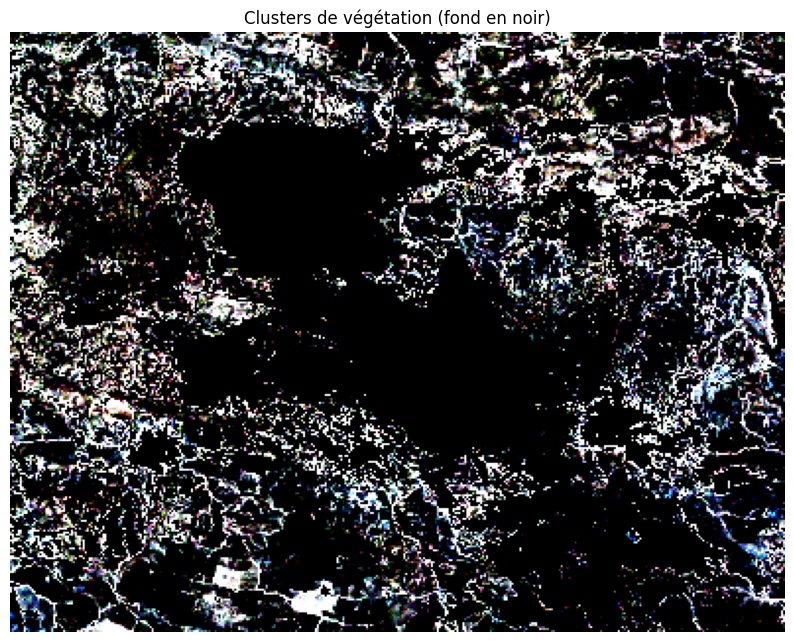

In [10]:
# Flatten mask
"""
veg_idx = veg_mask.flatten()

pixels = image.reshape(l, -1).T      # → (H*W, C)
veg_pixels = pixels[veg_idx]         # → (N_veg, C)
"""

image_path = r'./INSA_cropped_2_EnMAP_20240508.tif'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

# --- 9) Affichage ---
plt.figure(figsize=(10,10))
plt.imshow(img_scaled_veg_complete.reshape(m,n,l)[:,:,:3])
plt.axis('off')
plt.title("Clusters de végétation (fond en noir)")
plt.show()


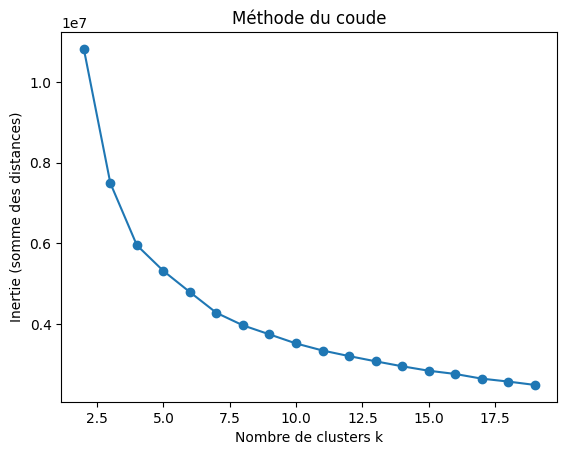

k optimal trouvé = 7


In [11]:
inertias = []
    #sil_scores = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_veg)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")

In [16]:
import xml.etree.ElementTree as ET
import re

def extract_wavelengths_from_auxxml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    wavelengths = []

    # Pour chaque bande dans l'ordre
    for band in root.findall(".//PAMRasterBand"):
        desc = band.find("Description")
        if desc is not None and desc.text:
            # Chercher un nombre suivi de "Nanometers"
            match = re.search(r"\(([\d.]+)\s*Nanometers\)", desc.text)
            if match:
                wl = float(match.group(1))
                wavelengths.append(wl)

    return wavelengths


# Exemple d'utilisation
xml_file = r"./INSA_cropped_2_EnMAP_20240508.tif.aux.xml"
wavelengths = extract_wavelengths_from_auxxml(xml_file)

print("Longueurs d’onde extraites :", wavelengths)
print("Nombre de bandes :", len(wavelengths))


Longueurs d’onde extraites : [418.416, 424.043, 429.457, 434.686, 439.757, 444.699, 449.539, 454.306, 459.031, 463.73, 468.411, 473.08, 477.744, 482.411, 487.087, 491.78, 496.497, 501.243, 506.02, 510.828, 515.672, 520.55, 525.467, 530.424, 535.422, 540.463, 545.551, 550.687, 555.873, 561.112, 566.405, 571.756, 577.166, 582.636, 588.171, 593.773, 599.446, 605.193, 611.017, 616.923, 622.92, 628.987, 635.112, 641.294, 647.537, 653.841, 660.207, 666.637, 673.131, 679.691, 686.319, 693.014, 699.78, 706.617, 713.524, 720.501, 727.545, 734.654, 741.826, 749.06, 756.353, 763.703, 771.108, 778.567, 786.078, 793.639, 801.248, 808.905, 816.608, 824.355, 832.145, 839.976, 847.847, 855.757, 863.703, 871.683, 879.692, 887.729, 895.789, 901.962, 903.87, 911.572, 911.968, 920.08, 921.32, 928.204, 931.204, 936.335, 941.218, 944.47, 951.361, 952.608, 960.748, 961.629, 968.891, 972.017, 977.037, 982.524, 985.186, 993.145, 993.338, 1003.88, 1014.72, 1025.66, 1036.7, 1047.84, 1059.07, 1070.39, 1081.79, 10

X_scaled shape : (79116, 219)
labels shape   : (79116,)
labels uniques : {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)}
Silhouette (échantillon) pour k = 7 : 0.268
Calinski-Harabasz pour k = 7 : 40269.48
(79116,)
(79116, 219)
            Bande_1   Bande_2   Bande_3   Bande_4   Bande_5   Bande_6  \
Cluster_1  0.036119  0.035271  0.038265  0.038679  0.039972  0.041203   
Cluster_2  0.038432  0.036983  0.039227  0.039093  0.040086  0.040959   
Cluster_3  0.026624  0.024662  0.025771  0.026509  0.026667  0.027007   
Cluster_4  0.025891  0.024285  0.025702  0.026506  0.026818  0.027414   
Cluster_5  0.047468  0.046720  0.049807  0.050196  0.052046  0.053472   
Cluster_6  0.030958  0.029115  0.030857  0.030843  0.031286  0.031822   
Cluster_7  0.023425  0.021219  0.021916  0.022841  0.022811  0.022970   

            Bande_7   Bande_8   Bande_9  Bande_10  ...  Bande_210  Bande_211  \
Cluster_1  0.043478  0.045629  0.046314  0.048292  ...   0.11654

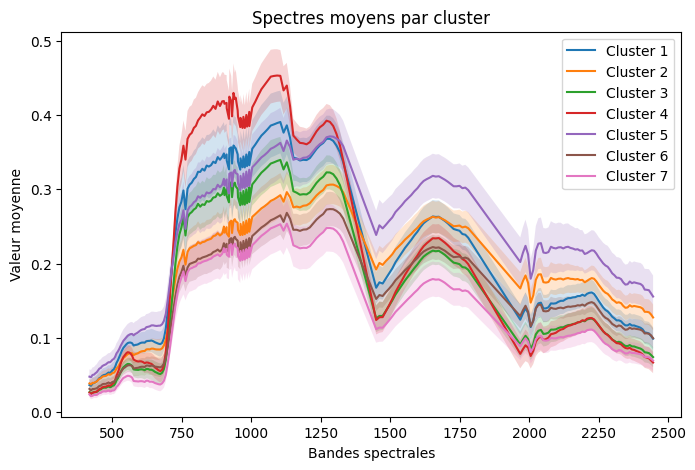

In [17]:
optimal_k = 7
# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels_veg = kmeans_final.fit_predict(X_scaled_veg)

print("X_scaled shape :", X_scaled_veg.shape)
print("labels shape   :", labels_veg.shape)
print("labels uniques :", set(labels_veg))

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_veg.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_veg = X_scaled_veg[idx]
    labels_sampled_veg = labels_veg[idx]
else:
    X_sampled_veg = X_scaled_veg
    labels_sampled_veg = labels_veg

sil_score = silhouette_score(X_sampled_veg, labels_sampled_veg)
ch_score  = calinski_harabasz_score(X_scaled_veg, labels_veg)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")

print(labels_veg.shape)
print(veg_pixels.shape)

# Calcul des moyennes par cluster
mean_spectra = np.zeros((optimal_k, veg_pixels.shape[1]))
std_spectra = np.zeros((optimal_k, veg_pixels.shape[1]))

for k in range(optimal_k):
    cluster_pixels = pixels[veg_mask_1d][labels_veg == k]
    mean_spectra[k] = cluster_pixels.mean(axis=0)
    std_spectra[k]  = cluster_pixels.std(axis=0)

# Option : afficher sous forme de tableau avec pandas
df_mean_spectra = pd.DataFrame(
    mean_spectra, 
    columns=[f'Bande_{i+1}' for i in range(veg_pixels.shape[1])]
)
df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]

print(df_mean_spectra)

plt.figure(figsize=(8,5))
bands = wavelengths

for k in range(optimal_k):
    plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
    plt.fill_between(
        bands,
        mean_spectra[k] - std_spectra[k],
        mean_spectra[k] + std_spectra[k],
        alpha=0.2
    )
plt.xlabel('Bandes spectrales')
plt.ylabel('Valeur moyenne')
plt.title('Spectres moyens par cluster')
plt.legend()
plt.show()

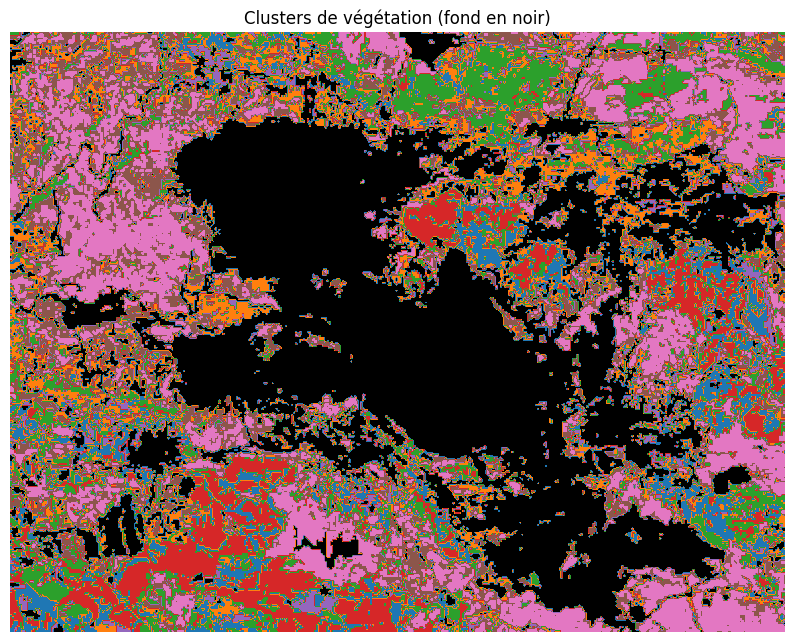

In [18]:
# --- 7) Construction de la carte finale ---
cluster_map = np.zeros((m, n), dtype=int)
cluster_map[veg_mask_2d] = labels_veg + 1  # 0 = fond, clusters à partir de 1

# --- 8) Création de la colormap ---
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
cmap = colors.ListedColormap(cmap_colors)

# --- 9) Affichage ---
plt.figure(figsize=(10,10))
plt.imshow(cluster_map, cmap=cmap)
plt.axis('off')
plt.title("Clusters de végétation (fond en noir)")
plt.show()

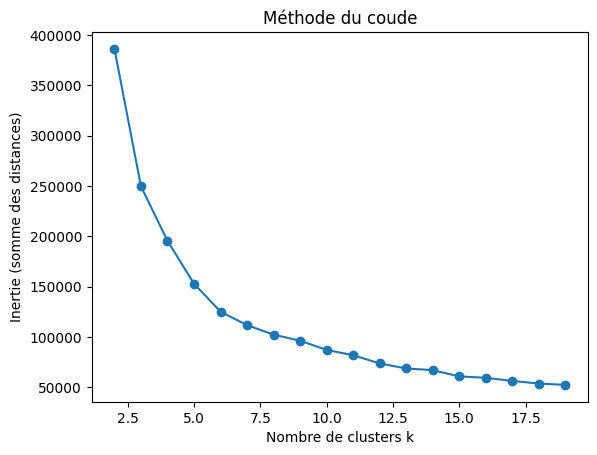

k optimal trouvé = 6


In [19]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

inertias = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_other)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")


6 classes pour le reste selon le critère du coude

X_scaled shape : (5409, 219)
labels shape   : (5409,)
labels uniques : {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}
Silhouette (échantillon) pour k = 6 : 0.481
Calinski-Harabasz pour k = 6 : 9139.13


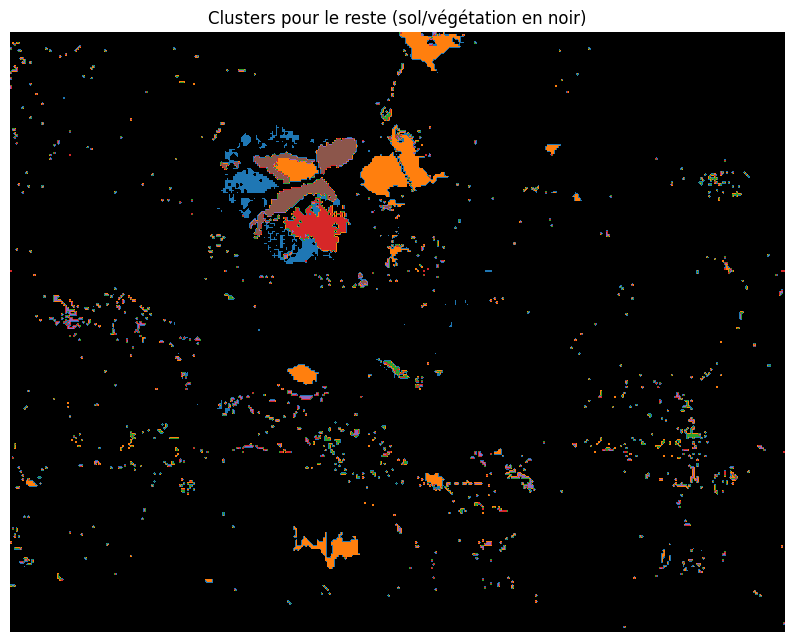

In [20]:
optimal_k = 6

# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels_other = kmeans_final.fit_predict(X_scaled_other)

print("X_scaled shape :", X_scaled_other.shape)
print("labels shape   :", labels_other.shape)
print("labels uniques :", set(labels_other))

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_other.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled_other[idx]
    labels_sampled = labels_other[idx]
else:
    X_sampled = X_scaled_other
    labels_sampled = labels_other

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled_other, labels_other)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")

# --- 7) Construction de la carte finale ---
cluster_map = np.zeros((m, n), dtype=int)
cluster_map[other_mask_2d] = labels_other + 1  # 0 = fond, clusters à partir de 1

# nombre de clusters sol
K = labels_other.max() + 1

# Création d'une colormap : noir pour 0, puis couleurs distinctes
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:K])
cmap = colors.ListedColormap(cmap_colors)

plt.figure(figsize=(10, 10))
plt.imshow(cluster_map, cmap=cmap)
plt.title("Clusters pour le reste (sol/végétation en noir)")
plt.axis("off")
plt.show()

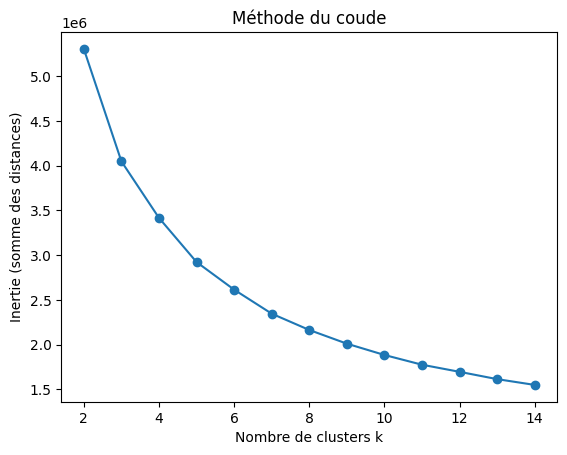

k optimal trouvé = 5


In [21]:
# Flatten mask

image_path = r'./INSA_cropped_2_EnMAP_20240508.tif'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)

inertias = []

K_range = range(2, 15, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_soil)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")


5 classes pour le sol selon le critère du coude...

(40788,)
(40788, 219)
       Cluster  Mean_std_all_bands
0    Cluster 1            0.072175
1    Cluster 2            0.018802
2    Cluster 3            0.015938
3    Cluster 4            0.030809
4    Cluster 5            0.018820
5    Cluster 6            0.022500
6    Cluster 7            0.018855
7    Cluster 8            0.021295
8    Cluster 9            0.034735
9   Cluster 10            0.032101
10  Cluster 11            0.029822
11  Cluster 12            0.018917
12  Cluster 13            0.024998
13  Cluster 14            0.020766
14  Cluster 15            0.022036
15  Cluster 16            0.025122
16  Cluster 17            0.025687
17  Cluster 18            0.015092
18  Cluster 19            0.019367
19  Cluster 20            0.025747
20  Cluster 21            0.043029
21  Cluster 22            0.036404
22  Cluster 23            0.024361
23  Cluster 24            0.016337
24  Cluster 25            0.016456
25  Cluster 26            0.026099
26  Cluster 27            0.01795

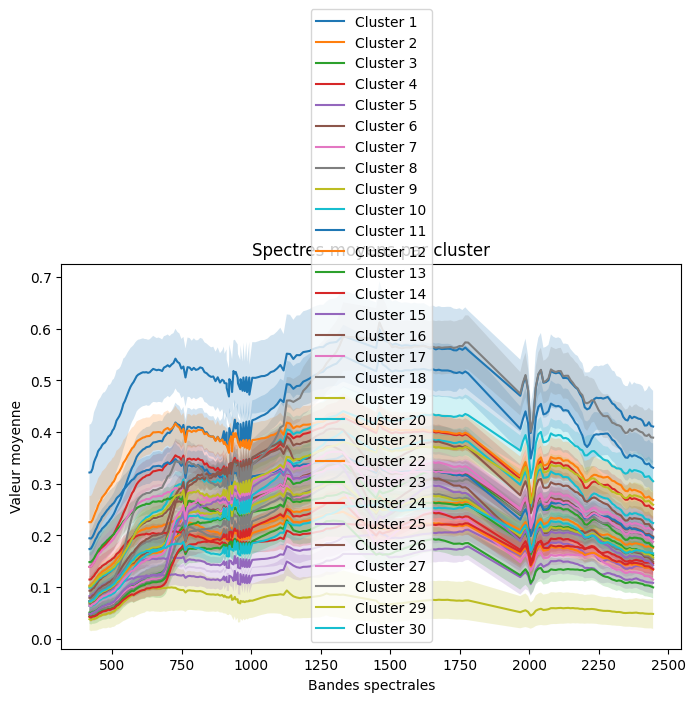

In [22]:
optimal_k = 30

# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels_soil = kmeans_final.fit_predict(X_scaled_soil)
print(labels_soil.shape)
print(soil_pixels.shape)

# Calcul des moyennes par cluster
mean_spectra = np.zeros((optimal_k, soil_pixels.shape[1]))
std_spectra = np.zeros((optimal_k, soil_pixels.shape[1]))
mean_std_per_cluster = np.zeros(optimal_k)

for k in range(optimal_k):
    cluster_pixels = soil_pixels[labels_soil == k]
    mean_spectra[k] = cluster_pixels.mean(axis=0)
    std_spectra[k]  = cluster_pixels.std(axis=0)
    mean_std_per_cluster[k] = std_spectra[k].mean() # moyenne de l'écart-type sur toutes les bandes

# Affichage sous forme de DataFrame
df = pd.DataFrame({
    'Cluster': [f'Cluster {i+1}' for i in range(optimal_k)],
    'Mean_std_all_bands': mean_std_per_cluster
})

# Option : afficher sous forme de tableau avec pandas
df_mean_spectra = pd.DataFrame(
    mean_spectra, 
    columns=[f'Bande_{i+1}' for i in range(soil_pixels.shape[1])]
)

print(df)
df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]

print(df_mean_spectra)

plt.figure(figsize=(8,5))
bands = wavelengths

for k in range(optimal_k):
    plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
    plt.fill_between(
        bands,
        mean_spectra[k] - std_spectra[k],
        mean_spectra[k] + std_spectra[k],
        alpha=0.2
    )
plt.xlabel('Bandes spectrales')
plt.ylabel('Valeur moyenne')
plt.title('Spectres moyens par cluster')
plt.legend()
plt.show()

Silhouette (échantillon) pour k = 30 : 0.185
Calinski-Harabasz pour k = 30 : 10426.59


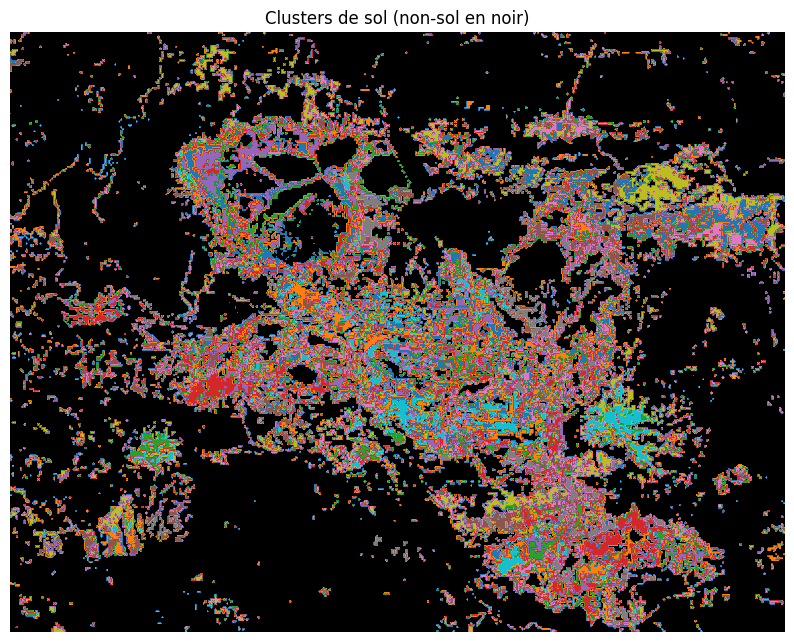

In [23]:
import matplotlib.colors as colors

k_soil = 30
kmeans = KMeans(n_clusters=k_soil, random_state=42)
labels = kmeans.fit_predict(X_scaled_soil)

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_soil.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled_soil[idx]
    labels_sampled = labels_soil[idx]
else:
    X_sampled = X_scaled_soil
    labels_sampled = labels_soil

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled_soil, labels_soil)

print(f"Silhouette (échantillon) pour k = {k_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {k_soil} : {ch_score:.2f}")

# Carte vide
cluster_map = np.zeros((m, n), dtype=int) 

# On "injecte" les labels K-means dans la carte finale
cluster_map[soil_mask_2d] = labels + 1

# nombre de clusters végétation
K = labels.max() + 1

# Création d'une colormap : noir pour 0, puis couleurs distinctes
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:K])
cmap = colors.ListedColormap(cmap_colors)

plt.figure(figsize=(10, 10))
plt.imshow(cluster_map, cmap=cmap)
plt.title("Clusters de sol (non-sol en noir)")
plt.axis("off")
plt.show()

In [24]:
class LinearAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super().__init__()

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, in_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [25]:
def train_autoencoder(model, dataloader, epochs, criterion, optimizer, device):
    for ep in range(epochs):
        model.train()
        loss_sum = 0
        for x, in dataloader:
            x = x.to(device)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{epochs}   Loss = {loss_sum/len(dataloader):.6f}")

In [26]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [27]:
import matplotlib.colors as mcolors

def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return mcolors.ListedColormap(colors)

In [28]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_veg = torch.tensor(X_scaled_veg, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_veg.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_veg = 7
    kmeans = KMeans(n_clusters_veg, n_init=5, random_state=0)
    labels_1d_veg = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_veg.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_veg = X_scaled_veg[idx]
    labels_sampled_veg = labels_1d_veg[idx]
else:
    X_sampled_veg = X_scaled_veg
    labels_sampled_veg = labels_1d_veg

sil_score = silhouette_score(X_sampled_veg, labels_sampled_veg)
ch_score  = calinski_harabasz_score(X_sampled_veg, labels_sampled_veg)

print(f"Silhouette (échantillon) pour k = {n_clusters_veg} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_veg} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.595409
Epoch 2/5   Loss = 0.545044
Epoch 3/5   Loss = 0.541446
Epoch 4/5   Loss = 0.540622
Epoch 5/5   Loss = 0.539804
Silhouette (échantillon) pour k = 7 : 0.212
Calinski-Harabasz pour k = 7 : 4243.06


In [29]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_soil = torch.tensor(X_scaled_soil, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_soil.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_soil = 30
    kmeans = KMeans(n_clusters_soil, n_init=5, random_state=0)
    labels_1d_soil = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_soil.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_soil = X_scaled_soil[idx]
    labels_sampled_soil = labels_1d_soil[idx]
else:
    X_sampled_soil = X_scaled_soil
    labels_sampled_soil = labels_1d_soil

sil_score = silhouette_score(X_sampled_soil, labels_sampled_soil)
ch_score  = calinski_harabasz_score(X_sampled_soil, labels_sampled_soil)

print(f"Silhouette (échantillon) pour k = {n_clusters_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_soil} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.683967
Epoch 2/5   Loss = 0.593370
Epoch 3/5   Loss = 0.587045
Epoch 4/5   Loss = 0.584590
Epoch 5/5   Loss = 0.581573
Silhouette (échantillon) pour k = 30 : 0.151
Calinski-Harabasz pour k = 30 : 2271.67


In [30]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_other = torch.tensor(X_scaled_other, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_other.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_other = 6
    kmeans = KMeans(n_clusters_other, n_init=5, random_state=0)
    labels_1d_other = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_other.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_other = X_scaled_other[idx]
    labels_sampled_other = labels_1d_other[idx]
else:
    X_sampled_other = X_scaled_other
    labels_sampled_other = labels_1d_other

sil_score = silhouette_score(X_sampled_other, labels_sampled_other)
ch_score  = calinski_harabasz_score(X_sampled_other, labels_sampled_other)

print(f"Silhouette (échantillon) pour k = {n_clusters_other} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_other} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.959178
Epoch 2/5   Loss = 0.615077
Epoch 3/5   Loss = 0.591114
Epoch 4/5   Loss = 0.569490
Epoch 5/5   Loss = 0.562815
Silhouette (échantillon) pour k = 6 : 0.439
Calinski-Harabasz pour k = 6 : 8183.11


In [ ]:
"""
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, input_size=128):
    
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, 2, 1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, 2, 1),          # H/8
            nn.ReLU(True),

            nn.Conv2d(128, 256, 3, 2, 1),         # H/16
            nn.ReLU(True),
        )

        # Calculer la taille du tenseur après convolutions
        conv_out_size = 256 * (input_size // 16) * (input_size // 16)

        # ------- LATENT VECTOR -------
        self.fc_enc = nn.Linear(conv_out_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, conv_out_size)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, 2, 1, 1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),    # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3, 2, 1, 1),  # H*2
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        batch_size = z.size(0)
        z = z.view(batch_size, -1)        # Flatten
        z = self.fc_enc(z)                # Latent vector

        # Decoder
        z = self.fc_dec(z)
        z = z.view(batch_size, 256, x.size(2)//16, x.size(3)//16)  # reshape pour decoder
        x_recon = self.decoder_conv(z)
        return x_recon
"""

'\nclass ConvAutoencoder(nn.Module):\n    def __init__(self, in_channels=3, latent_dim=128, input_size=128):\n    \n        super(ConvAutoencoder, self).__init__()\n\n        # ------- ENCODER -------\n        self.encoder_conv = nn.Sequential(\n            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2\n            nn.ReLU(True),\n\n            nn.Conv2d(32, 64, 3, 2, 1),           # H/4\n            nn.ReLU(True),\n\n            nn.Conv2d(64, 128, 3, 2, 1),          # H/8\n            nn.ReLU(True),\n\n            nn.Conv2d(128, 256, 3, 2, 1),         # H/16\n            nn.ReLU(True),\n        )\n\n        # Calculer la taille du tenseur après convolutions\n        conv_out_size = 256 * (input_size // 16) * (input_size // 16)\n\n        # ------- LATENT VECTOR -------\n        self.fc_enc = nn.Linear(conv_out_size, latent_dim)\n        self.fc_dec = nn.Linear(latent_dim, conv_out_size)\n\n        # ------- DECODER -------\n        self.decoder_conv = nn.Sequential(\n            nn.Conv

In [31]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=1, padding=1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),          # H/8
            nn.ReLU(True)
        )

        # Pas besoin de input_size fixe : taille après conv dépend du patch
        self.fc_enc = None  # on initialisera dynamiquement au premier forward
        self.fc_dec = None

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride= 1, padding=1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, stride=1, padding=1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3,stride= 1, padding=1),    # H*2
            nn.Sigmoid()
        )

        self.latent_dim = latent_dim
        self._fc_initialized = False

    def _init_fc(self, x):
        # Calculer la taille de flatten après encoder pour ce patch
        with torch.no_grad():
            z = self.encoder_conv(x)
            batch_size, c, h, w = z.size()
            self.fc_enc = nn.Linear(c*h*w, self.latent_dim)
            self.fc_dec = nn.Linear(self.latent_dim, c*h*w)
        self._fc_initialized = True

    def forward(self, x):
        if not self._fc_initialized:
            self._init_fc(x)
        # Encoder
        z = self.encoder_conv(x)
        batch_size, c, h, w = z.size()
        z_flat = z.view(batch_size, -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(batch_size, c, h, w)  # reshape exactement aux dimensions du conv
        x_recon = self.decoder_conv(z_dec)
        return x_recon, z_latent


In [32]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

In [33]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [34]:
import sys

print(img_scaled_veg_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_veg = torch.tensor(img_scaled_veg_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_veg.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_veg = 7
    kmeans = KMeans(n_clusters_veg, n_init=5, random_state=0)
    labels_1d_veg = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

X_sampled_veg = X_tensor_veg[total_idx]
labels_sampled_veg = labels_1d_veg

sil_score = silhouette_score(latent_vectors, labels_sampled_veg)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_veg)

print(f"Silhouette (échantillon) pour k = {n_clusters_veg} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_veg} : {ch_score:.2f}")

(120170, 219)
Epoch 1/5  Batch 10/10  Loss: 0.641542Epoch 1/5   Loss = 0.807131
Epoch 2/5  Batch 10/10  Loss: 0.661382Epoch 2/5   Loss = 0.659965
Epoch 3/5  Batch 10/10  Loss: 0.691900Epoch 3/5   Loss = 0.671928
Epoch 4/5  Batch 10/10  Loss: 0.649427Epoch 4/5   Loss = 0.633615
Epoch 5/5  Batch 10/10  Loss: 0.592313Epoch 5/5   Loss = 0.635802
Silhouette (échantillon) pour k = 7 : 0.411
Calinski-Harabasz pour k = 7 : 3534.77


In [36]:
print(img_scaled_soil_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_soil = torch.tensor(img_scaled_soil_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_soil.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_soil = 30
    kmeans = KMeans(n_clusters_soil, n_init=5, random_state=0)
    labels_1d_soil = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

X_sampled_soil = X_tensor_soil[total_idx]
labels_sampled_soil = labels_1d_soil

sil_score = silhouette_score(latent_vectors, labels_sampled_soil)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_soil)

print(f"Silhouette (échantillon) pour k = {n_clusters_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_soil} : {ch_score:.2f}")

(120170, 219)
Epoch 1/5  Batch 10/10  Loss: 0.360437Epoch 1/5   Loss = 0.493357
Epoch 2/5  Batch 10/10  Loss: 0.379081Epoch 2/5   Loss = 0.365238
Epoch 3/5  Batch 10/10  Loss: 0.270879Epoch 3/5   Loss = 0.319265
Epoch 4/5  Batch 10/10  Loss: 0.337584Epoch 4/5   Loss = 0.329330
Epoch 5/5  Batch 10/10  Loss: 0.362431Epoch 5/5   Loss = 0.340509
Silhouette (échantillon) pour k = 30 : 0.319
Calinski-Harabasz pour k = 30 : 806.23


In [38]:
print(img_scaled_other_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_other = torch.tensor(img_scaled_other_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_other.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_other = 6
    kmeans = KMeans(n_clusters_other, n_init=5, random_state=0)
    labels_1d_other = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

labels_sampled_other = labels_1d_other

sil_score = silhouette_score(latent_vectors, labels_sampled_other)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_other)

print(f"Silhouette (échantillon) pour k = {n_clusters_other} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_other} : {ch_score:.2f}")

(120170, 219)
Epoch 1/5  Batch 10/10  Loss: 0.178018Epoch 1/5   Loss = 0.254296
Epoch 2/5  Batch 10/10  Loss: 0.030621Epoch 2/5   Loss = 0.079324
Epoch 3/5  Batch 10/10  Loss: 0.036609Epoch 3/5   Loss = 0.039566
Epoch 4/5  Batch 10/10  Loss: 0.065308Epoch 4/5   Loss = 0.046099
Epoch 5/5  Batch 10/10  Loss: 0.036563Epoch 5/5   Loss = 0.045023
Silhouette (échantillon) pour k = 6 : 0.767
Calinski-Harabasz pour k = 6 : 3151.24


In [39]:
print(X_sampled_veg.shape)
print(labels_sampled_veg.shape)
print(len(total_idx))
print(latent_vectors.shape)

torch.Size([6400, 219])
(6400,)
6400
(6400, 128)


Nombre de clusters pour la végétation avec CAH

In [40]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')


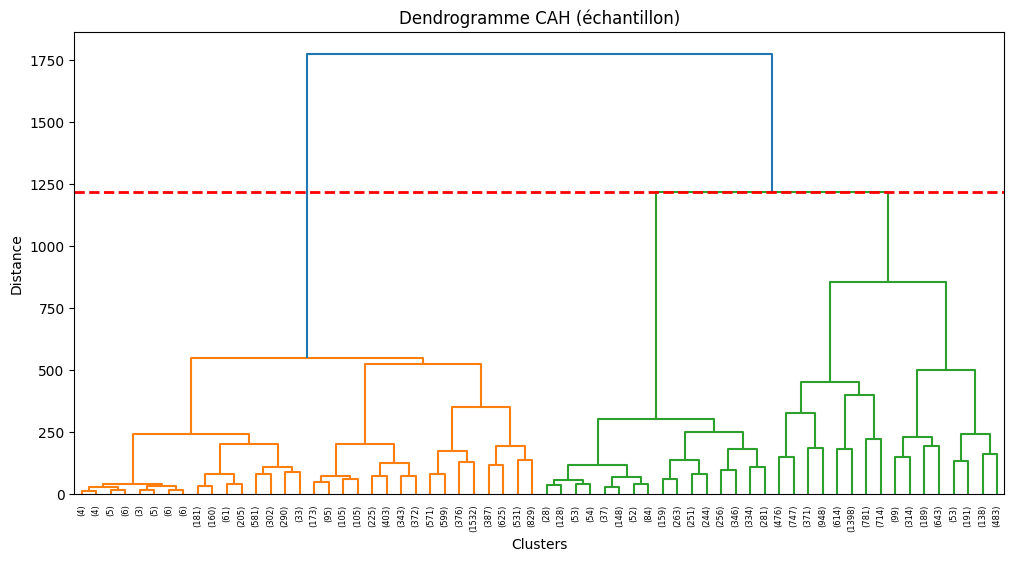

In [41]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

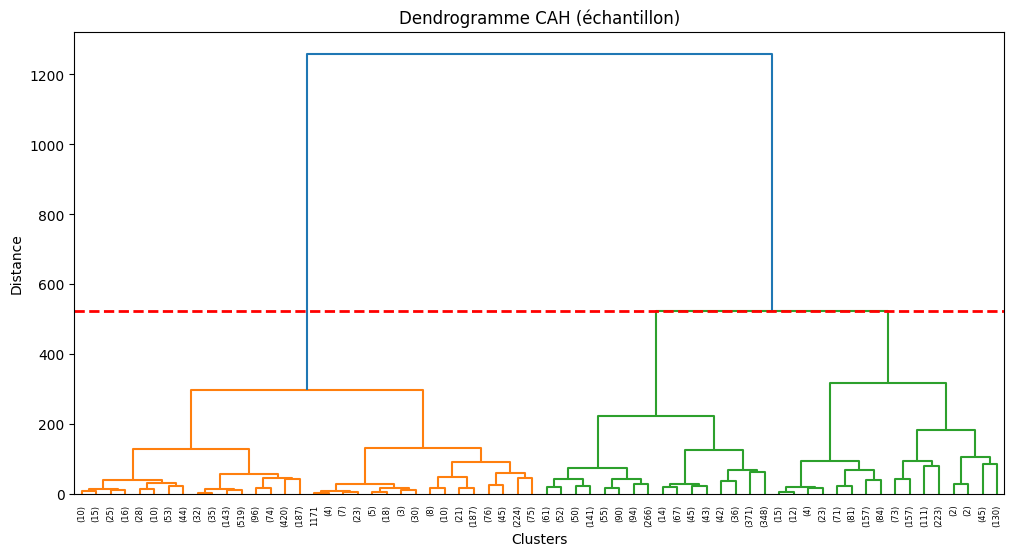

In [43]:
X_sample = X_scaled_other

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


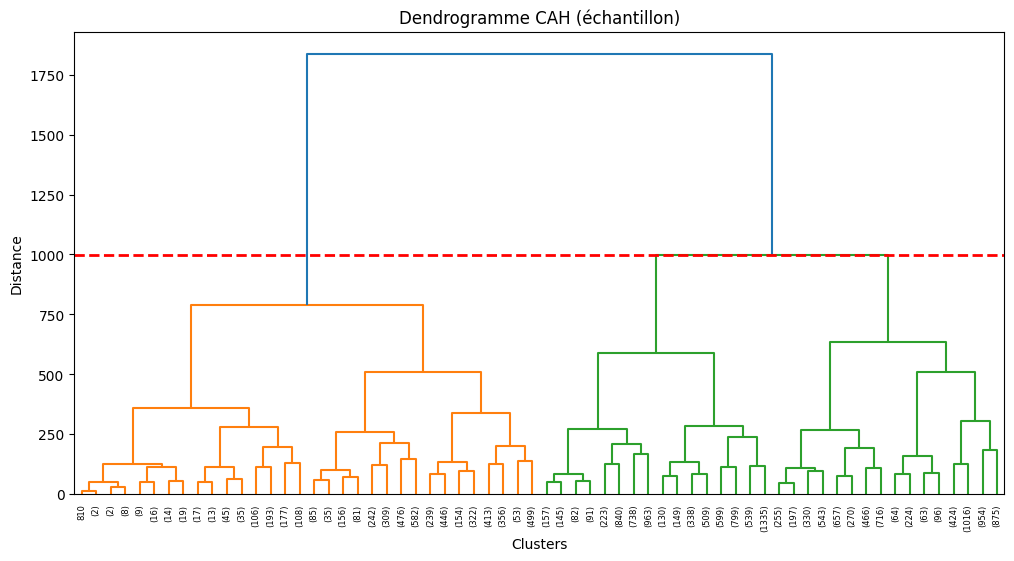

In [44]:
N = 20000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()